In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings

warnings.filterwarnings("ignore")

In [224]:
## Function cell

def split_vote_share(df):
    per = re.split("{([\d.]+)%\}", df)
    return float(per[1])

def party_name(df):
    name = re.split("{([\d.]+)%\}", df)
    return name[0].strip()

def clean_leading_party(df):
    d = re.sub(r'iParty.*',' ', df)
    return d.strip()

def short_name(df):
    if df == "Tamilaga Vettri Kazhagam":
        return "TVK"
    elif df == "Viduthalai Chiruthaigal Katchi":
        return "VCK"
    elif df == "Dravida Munnetra Kazhagam":
        return "DMK"
    elif df == "All India Anna Dravida Munnetra Kazhagam":
        return "AIADMK"
    elif df == "Indian National Congress":
        return "INC"
    elif df == "Bharatiya Janata Party":
        return "BJP"
    elif df == "Communist Party of India (Marxist)":
        return "CPI(M)"
    elif df == "Communist Party of India":
        return "CPI"
    elif df == "Pattali Makkal Katchi":
        return "PMK"
    elif df == "Desiya Murpokku Dravida Kazhagam":
        return "DMDK"
    elif df == "Amma Makkal Munnettra Kazagam":
        return "AMMK"
    elif df == "Indian Union Muslim League":
        return "IUML"
    else:
        return "Unknown"
        

In [225]:
df_results = pd.read_csv("C:\\Code Note\\TN26 ELECTION ANALYSIS\\data\\results_2026.csv")
df_vote_share = pd.read_csv("C:\\Code Note\\TN26 ELECTION ANALYSIS\\data\\party_vote_share.csv")
df_tn_2021 = pd.read_csv("C:\\Code Note\\TN26 ELECTION ANALYSIS\\data\\tn21_election_results.csv")

In [226]:
df_results.head()

,Constituency,Constituency No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Round,Status
0,ALANDUR,28,M.HARISH,Tamilaga Vettri KazhagamiParty Wise State Tren...,T.M.ANBARASAN,Dravida Munnetra Kazhagam\niParty Wise State T...,29609,31/31,Result Declared
1,ALANGUDI,182,SIVA.V.MEYYANATHAN,Dravida Munnetra KazhagamiParty Wise State Tre...,KANDASAMY,Tamilaga Vettri Kazhagam\niParty Wise State Tr...,12977,21/21,Result Declared
2,ALANGULAM,223,PAUL MANOJ PANDIAN,Dravida Munnetra KazhagamiParty Wise State Tre...,K R P PRABAKARAN,All India Anna Dravida Munnetra Kazhagam\niPar...,7798,25/25,Result Declared
3,AMBASAMUDRAM,225,DR.ESAKKI SUBAYA,All India Anna Dravida Munnetra KazhagamiParty...,V.P.DURAI,Indian National Congress\niParty Wise State Tr...,10245,23/23,Result Declared
4,AMBATTUR,8,BALAMURUGAN.G,Tamilaga Vettri KazhagamiParty Wise State Tren...,DR A.P. POORNIMA,Dravida Munnetra Kazhagam\niParty Wise State T...,58781,28/28,Result Declared


In [227]:
df_vote_share

,Party,Vote Share
0,TVK{34.92%},17226209
1,DMK{24.19%},11929144
2,ADMK{21.21%},10462146
3,Other{4.97%},2451413
4,NTK{4.00%},1972537
5,INC{3.37%},1661312
6,BJP{2.97%},1467024
7,DMDK{1.20%},589500
8,VCK{1.09%},540056
9,CPI{0.66%},326488


## Data Cleaning

In [228]:
df_vote_share['percentage'] = df_vote_share['Party'].apply(split_vote_share)
df_vote_share['Party'] = df_vote_share['Party'].apply(party_name)

In [229]:
df_results['Leading Party'] = df_results['Leading Party'].apply(clean_leading_party)
df_results['Trailing Party'] = df_results['Trailing Party'].apply(clean_leading_party)

In [230]:
df_results['Lead_Party_Name'] = df_results['Leading Party'].apply(short_name)
df_results['Trail_Party_Name'] = df_results['Trailing Party'].apply(short_name)

In [231]:
df_results.head()

,Constituency,Constituency No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Round,Status,Lead_Party_Name,Trail_Party_Name
0,ALANDUR,28,M.HARISH,Tamilaga Vettri Kazhagam,T.M.ANBARASAN,Dravida Munnetra Kazhagam,29609,31/31,Result Declared,TVK,DMK
1,ALANGUDI,182,SIVA.V.MEYYANATHAN,Dravida Munnetra Kazhagam,KANDASAMY,Tamilaga Vettri Kazhagam,12977,21/21,Result Declared,DMK,TVK
2,ALANGULAM,223,PAUL MANOJ PANDIAN,Dravida Munnetra Kazhagam,K R P PRABAKARAN,All India Anna Dravida Munnetra Kazhagam,7798,25/25,Result Declared,DMK,AIADMK
3,AMBASAMUDRAM,225,DR.ESAKKI SUBAYA,All India Anna Dravida Munnetra Kazhagam,V.P.DURAI,Indian National Congress,10245,23/23,Result Declared,AIADMK,INC
4,AMBATTUR,8,BALAMURUGAN.G,Tamilaga Vettri Kazhagam,DR A.P. POORNIMA,Dravida Munnetra Kazhagam,58781,28/28,Result Declared,TVK,DMK


## Feature Engineerig 

In [232]:
party_seats_df = df_results.groupby('Lead_Party_Name')['Leading Party'].count().reset_index()
party_seats_df.columns = ['Party', 'Seats']
party_seats_df = party_seats_df.sort_values(by='Seats', ascending=False).reset_index(drop=True)

In [233]:
party_seats_df

,Party,Seats
0,TVK,108
1,DMK,59
2,AIADMK,47
3,INC,5
4,PMK,4
5,CPI,2
6,CPI(M),2
7,IUML,2
8,VCK,2
9,AMMK,1


In [234]:
tamil_nadu_constituencies = {
    "Thiruvallur": [
        "Gummidipoondi", "Ponneri", "Thiruvallur", "Poonamallee", "Avadi",
        "Ambattur", "Madavaram", "Tiruttani"
    ],
    "Chennai": [
        "Thiruvottiyur", "Dr.radhakrishnan nagar", "Perambur", "Kolathur",
        "Villivakkam", "Thiru-vi-ka-nagar", "Egmore", "Royapuram",
        "Harbour", "Chepauk-thiruvallikeni", "Thousand lights", "Anna nagar",
        "Virugampakkam", "Saidapet", "Thiyagarayanagar", "Mylapore",
        "Velachery", "Shozhinganallur", "Maduravoyal"
    ],
    "Kancheepuram": [
        "Alandur", "Sriperumbudur", "Uthiramerur", "Kancheepuram"
    ],
    "Chengalpattu": [
        "Pallavaram", "Tambaram", "Chengalpattu", "Thiruporur",
        "Cheyyur", "Madurantakam"
    ],
    "Ranipet": [
        "Arakkonam", "Sholingur", "Ranipet", "Arcot"
    ],
    "Vellore": [
        "Katpadi", "Vellore", "Anaikattu", "Kilvaithinankuppam",
        "Gudiyattam"
    ],
    "Tirupattur": [
        "Vaniyambadi", "Ambur", "Tiruppattur"
    ],
    "Tiruvannamalai": [
        "Jolarpet", "Chengam", "Tiruvannamalai", "Kilpennathur",
        "Kalasapakkam", "Polur", "Arani", "Cheyyar", "Vandavasi"
    ],
    "Krishnagiri": [
        "Uthangarai", "Bargur", "Krishnagiri", "Veppanahalli",
        "Hosur", "Thalli"
    ],
    "Dharmapuri": [
        "Palacodu", "Pennagaram", "Dharmapuri", "Pappireddipatti",
        "Harur", "Mettur"
    ],
    "Viluppuram": [
        "Gingee", "Mailam", "Tindivanam", "Vanur",
        "Viluppuram", "Vikravandi"
    ],
    "Kallakurichi": [
        "Tirukkoyilur", "Ulundurpettai", "Rishivandiyam",
        "Sankarapuram", "Kallakurichi"
    ],
    "Salem": [
        "Gangavalli", "Attur", "Yercaud", "Omalur",
        "Edappadi", "Salem (west)", "Salem (north)", "Salem (south)",
        "Veerapandi"
    ],
    "Namakkal": [
        "Rasipuram", "Senthamangalam", "Namakkal",
        "Paramathi-velur", "Tiruchengodu", "Sankari"
    ],
    "Erode": [
        "Kumarapalayam", "Erode (east)", "Erode (west)", "Modakkurichi",
        "Perundurai", "Bhavani", "Anthiyur", "Gobichettipalayam",
        "Bhavanisagar"
    ],
    "Nilgiris": [
        "Udhagamandalam", "Gudalur", "Coonoor"
    ],
    "Tiruppur": [
        "Dharapuram", "Kangayam", "Avanashi", "Tiruppur (north)",
        "Tiruppur (south)", "Palladam", "Udumalaipettai", "Madathukulam"
    ],
    "Coimbatore": [
        "Mettuppalayam", "Sulur", "Kavundampalayam", "Coimbatore (north)",
        "Thondamuthur", "Coimbatore (south)", "Singanallur",
        "Kinathukadavu", "Pollachi", "Valparai"
    ],
    "Dindigul": [
        "Palani", "Oddanchatram", "Athoor", "Nilakkottai",
        "Natham", "Dindigul"
    ],
    "Karur": [
        "Vedasandur", "Aravakurichi", "Karur", "Krishnarayapuram",
        "Viralimalai"
    ],
    "Tiruchirappalli": [
        "Manapparai", "Srirangam", "Tiruchirappalli (west)",
        "Tiruchirappalli (east)", "Thiruverumbur", "Lalgudi",
        "Manachanallur", "Musiri", "Thuraiyur"
    ],
    "Perambalur": [
        "Kulithalai", "Perambalur", "Kunnam",
        "Ariyalur", "Jayankondam", "Tittakudi"
    ],
    "Ariyalur": [
        "Ariyalur", "Jayankondam"
    ],
    "Cuddalore": [
        "Tittakudi", "Vriddhachalam", "Neyveli", "Panruti",
        "Cuddalore", "Kurinjipadi", "Bhuvanagiri",
        "Chidambaram", "Kattumannarkoil"
    ],
    "Mayiladuthurai": [
        "Sirkazhi", "Mayiladuthurai", "Poompuhar"
    ],
    "Nagapattinam": [
        "Nagapattinam", "Kilvelur", "Vedaranyam", "Mannargudi"
    ],
    "Thiruvarur": [
        "Thiruthuraipoondi", "Thiruvarur", "Nannilam"
    ],
    "Thanjavur": [
        "Thiruvidaimarudur", "Kumbakonam", "Papanasam",
        "Thiruvaiyaru", "Thanjavur", "Orathanadu",
        "Pattukkottai", "Peravurani"
    ],
    "Pudukkottai": [
        "Gandharvakottai", "Viralimalai", "Pudukkottai",
        "Thirumayam", "Alangudi", "Aranthangi"
    ],
    "Sivaganga": [
        "Karaikudi", "Tiruppattur", "Sivaganga", "Manamadurai"
    ],
    "Madurai": [
        "Melur", "Madurai east", "Madurai north", "Madurai south",
        "Madurai central", "Madurai west", "Thiruparankundram",
        "Thirumangalam"
    ],
    "Theni": [
        "Sholavandan", "Usilampatti", "Andipatti",
        "Periyakulam", "Bodinayakanur", "Cumbum"
    ],
    "Virudhunagar": [
        "Rajapalayam", "Srivilliputhur", "Sattur",
        "Sivakasi", "Virudhunagar", "Aruppukkottai", "Tiruchuli"
    ],
    "Ramanathapuram": [
        "Tiruchuli", "Paramakudi", "Tiruvadanai",
        "Ramanathapuram", "Mudhukulathur"
    ],
    "Thoothukudi": [
        "Vilathikulam", "Thoothukkudi", "Tiruchendur",
        "Srivaikuntam", "Ottapidaram", "Kovilpatti"
    ],
    "Tenkasi": [
        "Sankarankovil", "Vasudevanallur",
        "Kadayanallur", "Tenkasi"
    ],
    "Tirunelveli": [
        "Alangulam", "Tirunelveli", "Ambasamudram",
        "Palayamkottai", "Nanguneri", "Radhapuram"
    ],
    "Kanniyakumari": [
        "Kanniyakumari", "Nagercoil", "Colachal",
        "Padmanabhapuram", "Vilavancode", "Killiyoor"
    ]
}

# Summary
print(f"Total Districts: {len(tamil_nadu_constituencies)}")
total = sum(len(v) for v in tamil_nadu_constituencies.values())
print(f"Total Constituencies: {total}")

Total Districts: 38
Total Constituencies: 239


In [235]:
df_results['Constituency'] = df_results['Constituency'].str.capitalize()

In [236]:
df_results[df_results['Constituency'] == "Hosur"]

,Constituency,Constituency No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Round,Status,Lead_Party_Name,Trail_Party_Name
55,Hosur,55,BALAKRISHNAREDDY. P,All India Anna Dravida Munnetra Kazhagam,VENDARKARASAN.S,Tamilaga Vettri Kazhagam,27803,32/32,Result Declared,AIADMK,TVK


In [237]:
for i, row in df_results.iterrows():
    constituency = row['Constituency']
    found = False
    for district, constituencies in tamil_nadu_constituencies.items():
        if constituency in constituencies:
            df_results.at[i, 'District'] = district
            found = True
            break
    if not found:
        df_results.at[i, 'District'] = "Unknown"

In [238]:
df_results[df_results['District'] == "Unknown"]

,Constituency,Constituency No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Round,Status,Lead_Party_Name,Trail_Party_Name,District


In [239]:
df_districts = df_results.groupby('District')['Lead_Party_Name'].value_counts().unstack(fill_value=0)

In [240]:
df_districts.head()

Lead_Party_Name,AIADMK,AMMK,BJP,CPI,CPI(M),DMDK,DMK,INC,IUML,PMK,TVK,VCK
District,,,,,,,,,,,,
Chengalpattu,2,0,0,0,0,0,0,0,0,0,4,0
Chennai,0,0,0,0,0,0,2,0,0,0,17,0
Coimbatore,1,0,0,0,0,0,3,0,0,0,6,0
Cuddalore,3,0,0,0,0,1,2,0,0,0,1,1
Dharmapuri,4,0,0,0,0,0,0,0,0,1,1,0


### TVK Analysis

In [241]:
df_results[(df_results['Lead_Party_Name'] == "TVK") & (df_results['Margin'] > 10000)]

,Constituency,Constituency No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Round,Status,Lead_Party_Name,Trail_Party_Name,District
0,Alandur,28,M.HARISH,Tamilaga Vettri Kazhagam,T.M.ANBARASAN,Dravida Munnetra Kazhagam,29609,31/31,Result Declared,TVK,DMK,Kancheepuram
4,Ambattur,8,BALAMURUGAN.G,Tamilaga Vettri Kazhagam,DR A.P. POORNIMA,Dravida Munnetra Kazhagam,58781,28/28,Result Declared,TVK,DMK,Thiruvallur
8,Anna nagar,21,V.K.RAMKUMAR,Tamilaga Vettri Kazhagam,N.CHITRARASU,Dravida Munnetra Kazhagam,21363,20/20,Result Declared,TVK,DMK,Chennai
10,Arakkonam,38,V. GANDHIRAJ,Tamilaga Vettri Kazhagam,EZHIL CAROLINE,Viduthalai Chiruthaigal Katchi,23121,22/22,Result Declared,TVK,VCK,Ranipet
12,Aranthangi,183,MOHAMED FARVAS. J,Tamilaga Vettri Kazhagam,RAMACHANDRAN . T,Indian National Congress,10062,23/23,Result Declared,TVK,INC,Pudukkottai
...,...,...,...,...,...,...,...,...,...,...,...,...
202,Tiruppur (south),114,BALAMURUGAN. S,Tamilaga Vettri Kazhagam,DINESHKUMAR. N,Dravida Munnetra Kazhagam,12901,21/21,Result Declared,TVK,DMK,Tiruppur
212,Uthiramerur,36,MUNIRATHINAM.J,Tamilaga Vettri Kazhagam,SUNDAR.K,Dravida Munnetra Kazhagam,14223,24/24,Result Declared,TVK,DMK,Kancheepuram
221,Velachery,26,KUMAR. R,Tamilaga Vettri Kazhagam,ASHOK. M.K,All India Anna Dravida Munnetra Kazhagam,33305,23/23,Result Declared,TVK,AIADMK,Chennai
227,Villivakkam,14,AADHAV ARJUNA,Tamilaga Vettri Kazhagam,KARTHIK MOHAN,Dravida Munnetra Kazhagam,17302,19/19,Result Declared,TVK,DMK,Chennai


In [242]:
df_results[(df_results['Trail_Party_Name'] == "TVK") & (df_results['Margin'] < 5000)]

,Constituency,Constituency No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Round,Status,Lead_Party_Name,Trail_Party_Name,District
16,Aruppukkottai,207,RAMACHANDRAN. K.K.S.S.R,Dravida Munnetra Kazhagam,KARTHIK KUMAR. K,Tamilaga Vettri Kazhagam,4943,20/20,Result Declared,DMK,TVK,Virudhunagar
21,Bargur,52,E.C. GOVINDARASAN,All India Anna Dravida Munnetra Kazhagam,E. MURALIDHARAN,Tamilaga Vettri Kazhagam,4241,24/24,Result Declared,AIADMK,TVK,Krishnagiri
33,Coimbatore (south),120,V SENTHILBALAJI,Dravida Munnetra Kazhagam,V. SENTHILKUMAR,Tamilaga Vettri Kazhagam,2271,20/20,Result Declared,DMK,TVK,Coimbatore
34,Colachal,231,THARAHAI CUTHBERT,Indian National Congress,PREM ALEX LAWRENCE,Tamilaga Vettri Kazhagam,2833,28/28,Result Declared,INC,TVK,Kanniyakumari
40,Dindigul,132,SENTHILKUMAR. I.P,Dravida Munnetra Kazhagam,NAZEER RAJA. G,Tamilaga Vettri Kazhagam,1131,26/26,Result Declared,DMK,TVK,Dindigul
65,Karur,135,M.R. VIJAYABHASKAR,All India Anna Dravida Munnetra Kazhagam,MATHIYALAGAN V.P,Tamilaga Vettri Kazhagam,1821,21/21,Result Declared,AIADMK,TVK,Karur
69,Killiyoor,234,RAJESH KUMAR. S,Indian National Congress,SABIN. S,Tamilaga Vettri Kazhagam,1311,23/23,Result Declared,INC,TVK,Kanniyakumari
72,Kilvelur,164,LATHA. T,Communist Party of India (Marxist),SENTHIL PANDIAN. P,Tamilaga Vettri Kazhagam,2278,17/17,Result Declared,CPI(M),TVK,Nagapattinam
75,Kovilpatti,218,KARUNANITHI.K,Dravida Munnetra Kazhagam,BALASUBRAMANIAN.S,Tamilaga Vettri Kazhagam,843,25/25,Result Declared,DMK,TVK,Thoothukudi
78,Kulithalai,137,SURIYANUR. A. CHANDRAN,Dravida Munnetra Kazhagam,G.BALASUBRAMANI,Tamilaga Vettri Kazhagam,579,21/21,Result Declared,DMK,TVK,Perambalur


In [243]:
df_results.tail(5)

,Constituency,Constituency No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Round,Status,Lead_Party_Name,Trail_Party_Name,District
229,Viralimalai,179,VIJAYABASKAR. C,All India Anna Dravida Munnetra Kazhagam,MURUGESAN. P,Tamilaga Vettri Kazhagam,62073,22/22,Result Declared,AIADMK,TVK,Karur
230,Virudhunagar,206,SELVAM P,Tamilaga Vettri Kazhagam,VIJAYAPRABHAKAR,Desiya Murpokku Dravida Kazhagam,9391,23/23,Result Declared,TVK,DMDK,Virudhunagar
231,Virugampakkam,22,SABARINATHAN.R,Tamilaga Vettri Kazhagam,PRABHAKARA RAJA.A.M.V,Dravida Munnetra Kazhagam,27086,24/24,Result Declared,TVK,DMK,Chennai
232,Vriddhachalam,152,PREMALLATHA VIJAYAKANT,Desiya Murpokku Dravida Kazhagam,VIJAY.S,Tamilaga Vettri Kazhagam,2387,24/24,Result Declared,DMDK,TVK,Cuddalore
233,Yercaud,83,USHARANI. P,All India Anna Dravida Munnetra Kazhagam,LAKSHMI JANARTHANAN. J,Tamilaga Vettri Kazhagam,2189,25/25,Result Declared,AIADMK,TVK,Salem


In [244]:
TVK_26 = df_results[df_results['Lead_Party_Name'] == "TVK"]['Constituency']

### Let's take look into tvk seats grapped from which parties from 21 election

In [245]:
df_tn_2021.head()

,No.,Name,%,Candidate,Party,Votes,%.1,Candidate.1,Party.1,Votes.1,%.2,Margin
0,1,Gummidipoondi,78.84,T. J. Govindrajan,DMK,"126,452",56.94,Prakash M,PMK,"75,514",34.00,"50,938"
1,2,Ponneri(SC),78.68,Durai Chandrasekar,INC,"94,528",44.94,P. Balaraman,ADMK,"84,839",40.33,"9,689"
2,3,Tiruttani,79.85,S. Chandran,DMK,"120,314",51.72,G. Hari,ADMK,"91,061",39.15,"29,253"
3,4,Thiruvallur,77.91,V. G. Raajendran,DMK,"107,709",50.27,B. V. Ramanaa,ADMK,"85,008",39.68,"22,701"
4,5,Poonamallee(SC),73.62,A. Krishnaswamy,DMK,"149,578",56.72,S. X. Rajamannar,PMK,"55,468",21.03,"94,110"


In [246]:
df_tn_2021.rename(columns={'Party': 'Winning Party', 'Party.1': 'Runner-up Party',
                           'Votes.1': 'Runner-up Votes', 'Name:': 'Constituency', 'Candidate': 'Winning Candidate',
                           'Candidate.1': 'Runner-up Candidate', '%': 'Vote Share', '%.1': 'Winner\'s Vote Share',
                           '%.2': 'Runner-up Vote Share'}, inplace=True)

In [247]:
df_tn_2021['Name'].str.capitalize()

0        Gummidipoondi
1          Ponneri(sc)
2            Tiruttani
3          Thiruvallur
4      Poonamallee(sc)
            ...       
229          Nagercoil
230           Colachel
231    Padmanabhapuram
232        Vilavancode
233          Killiyoor
Name: Name, Length: 234, dtype: object

In [248]:
df_tn_2021[df_tn_2021['Name'].str.contains('(SC)', case=False)].head(2)

,No.,Name,Vote Share,Winning Candidate,Winning Party,Votes,Winner's Vote Share,Runner-up Candidate,Runner-up Party,Runner-up Votes,Runner-up Vote Share,Margin
1,2,Ponneri(SC),78.68,Durai Chandrasekar,INC,"94,528",44.94,P. Balaraman,ADMK,"84,839",40.33,"9,689"
4,5,Poonamallee(SC),73.62,A. Krishnaswamy,DMK,"149,578",56.72,S. X. Rajamannar,PMK,"55,468",21.03,"94,110"


In [249]:
df_tn_2021['Name'] = df_tn_2021['Name'].str.replace(r'\(SC\)', '', regex=True).str.strip()

In [250]:
df_tn_2021[df_tn_2021['Name'].str.contains('Hosur', case=False)]

,No.,Name,Vote Share,Winning Candidate,Winning Party,Votes,Winner's Vote Share,Runner-up Candidate,Runner-up Party,Runner-up Votes,Runner-up Vote Share,Margin
54,55,Hosur,70.53,Y. Prakaash,DMK,"118,231",47.65,S. Jyothi Balakrishna Reddy,ADMK,"105,864",42.67,"12,367"


In [251]:
A = set(df_results['Constituency'])
B = set(df_tn_2021['Name'])

if A == B:
    print("Both sets are equal.")
else:
    print(f"In A but not in B: {A - B}")
    print(f"In B but not in A: {B - A}")

In A but not in B: {'Senthamangalam', 'Erode (east)', 'Yercaud', 'Tiruppur (south)', 'Salem (north)', 'Mettuppalayam', 'Anna nagar', 'Erode (west)', 'Pappireddipatti', 'Madurai west', 'Thiru-vi-ka-nagar', 'Tiruchirappalli (east)', 'Tiruppattur', 'Viluppuram', 'Madurai north', 'Tiruchengodu', 'Coimbatore (north)', 'Coimbatore (south)', 'Salem (west)', 'Tiruppur (north)', 'Chepauk-thiruvallikeni', 'Paramathi-velur', 'Colachal', 'Madurantakam', 'Madurai east', 'Thousand lights', 'Tiruchirappalli (west)', 'Madurai south', 'Thiyagarayanagar', 'Salem (south)', 'Dr.radhakrishnan nagar', 'Palacodu', 'Thirumangalam', 'Nilakkottai', 'Madurai central', 'Manapparai'}
In B but not in A: {'Nilakottai', 'Erode (East)', 'Anna Nagar', 'Madurai North', 'Tiruppur (South)', 'Paramathi-Velur', 'Madurai Central', 'Tiruchirappalli (East)', 'Tiruppattur(Sivaganga)', 'Coimbatore (North)', 'Manapaarai', 'Tiruchirappalli (West)', 'Erode (West)', 'Pappireddippatti', 'Thousand Lights', 'Thiyagaraya Nagar', 'Dr. Ra

In [252]:
from rapidfuzz import process

def match_name(name, choices, threshold=80):
    match = process.extractOne(name, choices)
    if match and match[1] >= threshold:
        return match[0]
    return name  # keep original if no good match

# Build a mapping from B -> A
mapping = {b: match_name(b, A) for b in B if b not in A}
print(mapping)

{'Erode (East)': 'Erode (east)', 'Tiruppur (South)': 'Tiruppur (south)', 'Paramathi-Velur': 'Paramathi-velur', 'Tiruppattur(Sivaganga)': 'Sivaganga', 'Tiruchirappalli (West)': 'Tiruchirappalli (east)', 'Salem (West)': 'Salem (west)', 'Colachel': 'Colachal', 'Villupuram': 'Viluppuram', 'Yercaud(ST)': 'Yercaud', 'Tiruchengode': 'Tiruchengodu', 'Tiruppur (North)': 'Tiruppur (north)', 'Mettupalayam': 'Mettuppalayam', 'Nilakottai': 'Nilakkottai', 'Madurai Central': 'Madurai central', 'Coimbatore (North)': 'Coimbatore (north)', 'Pappireddippatti': 'Pappireddipatti', 'Thiyagaraya Nagar': 'Thiyagarayanagar', 'Madurai South': 'Madurai south', 'Anna Nagar': 'Anna nagar', 'Madurai North': 'Madurai north', 'Tiruchirappalli (East)': 'Tiruchirappalli (east)', 'Manapaarai': 'Manapparai', 'Erode (West)': 'Erode (east)', 'Dr. Radhakrishnan Nagar': 'Dr.radhakrishnan nagar', 'Maduranthakam': 'Madurantakam', 'Madurai East': 'Madurai east', 'Salem (North)': 'Salem (north)', 'Senthamangalam(ST)': 'Senthaman

In [253]:
df_tn_2021['Name'] = df_tn_2021['Name'].replace(mapping)
# df_results['Constituency'] = df_results['Constituency'].replace(mapping1)

In [254]:
### debug: verfication
A = set(df_results['Constituency'])
B = set(df_tn_2021['Name'])

if A == B:
    print("Both sets are equal.")
else:
    print(f"In A but not in B: {A - B}")
    print(f"In B but not in A: {B - A}")

In A but not in B: {'Tiruchirappalli (west)', 'Madurai west', 'Tiruppattur', 'Erode (west)'}
In B but not in A: set()


In [255]:
# changes to be made in the future:
df_tn_2021.loc[193, "Name"] = "Madurai west"
df_tn_2021.loc[98, "Name"] = "Erode (west)"
df_tn_2021.loc[139, "Name"] = "Tiruchirappalli (west)"

In [256]:
tn21_win_party = df_tn_2021['Winning Party'].unique()

In [257]:
party_won = df_tn_2021['Winning Party'].value_counts()

In [258]:
# DMK_21 = df_tn_2021[df_tn_2021['Winning Party'] == "DMK"]['Name']
# ADMK_21 = df_tn_2021[df_tn_2021['Winning Party'] == "ADMK"]['Name']

party_21 = {
    party: df_tn_2021[df_tn_2021['Winning Party'] == party]['Name']
    for party in tn21_win_party
}

TVK won 63 seats from DMK and percentage of seats grabbed from DMK is 47.73%
TVK won 11 seats from INC and percentage of seats grabbed from INC is 61.11%
TVK won 1 seats from VCK and percentage of seats grabbed from VCK is 25.00%
TVK won 26 seats from ADMK and percentage of seats grabbed from ADMK is 39.39%
TVK won 0 seats from CPI and percentage of seats grabbed from CPI is 0.00%
TVK won 2 seats from PMK and percentage of seats grabbed from PMK is 40.00%
TVK won 1 seats from KMDK and percentage of seats grabbed from KMDK is 100.00%
TVK won 2 seats from BJP and percentage of seats grabbed from BJP is 50.00%
TVK won 1 seats from CPI(M) and percentage of seats grabbed from CPI(M) is 50.00%
TVK won 1 seats from other parties.


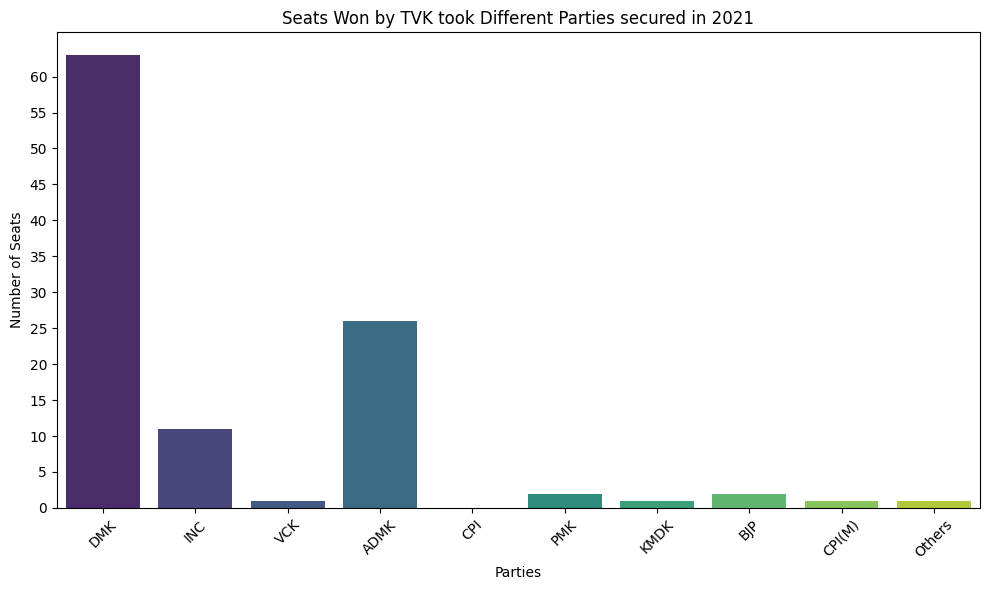

In [259]:
results = {}
for party in tn21_win_party:
    count = sum(seat in party_21[party].values for seat in TVK_26)
    results[party] = count

others = len(TVK_26) - sum(results.values())

for party, count in results.items():
    print(f"TVK won {count} seats from {party} and percentage of seats grabbed from {party} is {(count/party_won[party])*100:.2f}%")
print(f"TVK won {others} seats from other parties.")

parities = list(results.keys()) + ["Others"]
count = list(results.values()) + [others]

plt.figure(figsize=(10, 6))
sns.barplot(x=parities, y=count, palette="viridis")
plt.title("Seats Won by TVK took Different Parties secured in 2021")
plt.xlabel("Parties")
plt.ylabel("Number of Seats")
plt.xticks(rotation=45)
plt.yticks(range(0, max(count) + 1, 5))
plt.tight_layout()
plt.show()

In [260]:
party_won

Winning Party
DMK       132
ADMK       66
INC        18
PMK         5
VCK         4
BJP         4
CPI         2
CPI(M)      2
KMDK        1
Name: count, dtype: int64

In [262]:
DMK_SEAT, ADMK_SEAT, others = 0, 0, 0
for seat in TVK_26:
    if seat in DMK_21.values:
        DMK_SEAT += 1
    elif seat in ADMK_21.values:
        ADMK_SEAT += 1
    else:
        others += 1
print(f"TVK won {DMK_SEAT} seats from DMK, {ADMK_SEAT} seats from ADMK and {others} seats from other parties.")

TVK won 47 seats from DMK, 20 seats from ADMK and 41 seats from other parties.


In [104]:
party_21['DMK']

0        Gummidipoondi
2            Tiruttani
3          Thiruvallur
4          Poonamallee
5                Avadi
            ...       
218      Sankarankovil
219     Vasudevanallur
225      Palayamkottai
227         Radhapuram
231    Padmanabhapuram
Name: Name, Length: 132, dtype: object

In [105]:
df_results.head(1)

,Constituency,Constituency No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Round,Status,Lead_Party_Name,Trail_Party_Name,District
0,Alandur,28,M.HARISH,Tamilaga Vettri Kazhagam,T.M.ANBARASAN,Dravida Munnetra Kazhagam,29609,31/31,Result Declared,TVK,DMK,Kancheepuram


In [263]:
DMK26 = df_results[df_results['Lead_Party_Name'] == "DMK"]['Constituency']

In [264]:
cnt =0
for constituency in DMK26:
    if constituency in party_21['DMK'].values:
        cnt += 1
        print(f"{constituency} was with hold by DMK in 26 election")
    else:
        print(f"{constituency} was lost and with hold by DMK in 26 election")

print(f"Total {cnt} constituencies were with hold by DMK in 26 election")

Alangudi was with hold by DMK in 26 election
Alangulam was lost and with hold by DMK in 26 election
Ambur was with hold by DMK in 26 election
Andipatti was with hold by DMK in 26 election
Aravakurichi was with hold by DMK in 26 election
Aruppukkottai was with hold by DMK in 26 election
Athoor was with hold by DMK in 26 election
Bodinayakanur was lost and with hold by DMK in 26 election
Chepauk-thiruvallikeni was with hold by DMK in 26 election
Chidambaram was lost and with hold by DMK in 26 election
Coimbatore (south) was lost and with hold by DMK in 26 election
Coonoor was with hold by DMK in 26 election
Dindigul was lost and with hold by DMK in 26 election
Gudalur was lost and with hold by DMK in 26 election
Harbour was with hold by DMK in 26 election
Kadayanallur was lost and with hold by DMK in 26 election
Kovilpatti was lost and with hold by DMK in 26 election
Kulithalai was with hold by DMK in 26 election
Kunnam was with hold by DMK in 26 election
Kurinjipadi was with hold by DMK

In [265]:
df_results[df_results['Constituency'].str.contains('Tiruppattur', case=False)]

,Constituency,Constituency No.,Leading Candidate,Leading Party,Trailing Candidate,Trailing Party,Margin,Round,Status,Lead_Party_Name,Trail_Party_Name,District
199,Tiruppattur,50,DR.THIRUPATHI. N,Tamilaga Vettri Kazhagam,NALLATHAMBI. A,Dravida Munnetra Kazhagam,48263,23/23,Result Declared,TVK,DMK,Tirupattur
200,Tiruppattur,185,SEENIVASA SETHUPATHY. R,Tamilaga Vettri Kazhagam,PERIAKARUPPAN. KR,Dravida Munnetra Kazhagam,1,30/30,Result Declared,TVK,DMK,Tirupattur


In [ ]:
tn21_